In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

C:\Users\hercd\AppData\Local\Temp\ipykernel_16972\3380472518.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
pd.set_option('display.max_columns', None)

In [2]:
kwh_data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_Data_Model_Train.csv", index_col= 'datetime', parse_dates= True)
kwh_data

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_16972\3406061814.py:1: SyntaxWarning: invalid escape sequence '\D'
  kwh_data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_Data_Model_Train.csv", index_col= 'datetime', parse_dates= True)


,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,...,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,...,21.6,240.0,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,...,21.2,311.1,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,...,11.8,305.0,30.0,0.0,2,2,0,0,2,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,...,22.3,311.0,0.0,0.0,2,0,2,0,0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,...,22.3,306.5,0.0,0.0,2,0,2,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,25.7,42.86,17.6,290.0,...,20.9,180.0,50.0,121.0,2,2,2,2,2,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,24.4,45.20,15.8,209.0,...,17.3,170.2,50.0,71.0,5,2,2,2,2,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,22.4,50.62,5.0,304.0,...,15.1,0.0,50.0,44.0,5,2,2,5,2,0.0000


In [3]:
kwh_data['Kwh Target'] = kwh_data['Kwh']
kwh_data.head(30)

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,...,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,...,240.0,0.0,0.0,0,0,0,0,0,0.0000,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,...,311.1,0.0,0.0,0,0,0,0,0,0.0000,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,...,305.0,30.0,0.0,2,2,0,0,2,0.0000,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,...,311.0,0.0,0.0,2,0,2,0,0,0.0000,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,...,306.5,0.0,0.0,2,0,2,0,0,0.0000,0.0000
2022-01-01 05:00:00,3.0,93.11,19.6,296.0,39.6,0.0,4.7,85.36,36.1,270.0,...,306.8,0.1,0.0,2,0,0,0,0,0.0000,0.0000
2022-01-01 06:00:00,4.0,86.80,20.9,360.0,44.7,0.0,4.0,88.68,19.1,360.0,...,360.0,0.6,0.0,2,0,1,0,0,0.0000,0.0000
2022-01-01 07:00:00,6.0,75.51,22.3,340.0,63.9,0.0,5.4,78.73,20.2,340.0,...,340.0,8.3,0.0,2,2,1,0,0,0.0000,0.0000
2022-01-01 08:00:00,5.0,80.95,22.3,340.0,49.9,6.0,5.6,80.29,20.5,323.0,...,340.0,50.0,0.1,2,2,2,2,2,0.0305,0.0305


In [4]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :kwh_data.shape[1] - 1])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,...,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,...,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,...,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,...,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,...,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,...,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,...,0.673532,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,...,0.887028,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,...,0.998860,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,-1.009887,1.139773,0.682794,0.259345,...,1.181857,0.875291,0.170066,-0.516372,0.662831,0.249815,0.540307,0.467173,0.377153,-0.234996


In [5]:
df_scaled_kwh.index = kwh_data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,...,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,...,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,...,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,...,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,...,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,1.318702,-0.971041,0.189893,0.640784,...,0.378703,0.079023,0.170066,-0.274270,0.662831,0.249815,0.540307,0.467173,0.377153,-0.414121
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,1.167343,-0.857520,0.015929,-0.002894,...,0.012709,0.008083,0.170066,-0.453075,3.349560,0.249815,0.540307,0.467173,0.377153,-0.641731
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.934485,-0.594578,-1.027860,0.752037,...,-0.210954,-1.223961,0.170066,-0.549630,3.349560,0.249815,0.540307,3.084813,0.377153,-0.679890


In [6]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh Target"]], axis=1)
df_scaled_kwh.head(30)

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,...,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,...,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,...,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,...,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,...,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,...,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,...,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,...,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,...,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965,0.0305


In [19]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=5)
reshaped_df


,01,11,21,31,41,51,61,71,81,91,...,275,285,295,305,315,325,335,345,355,Kwh Target
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,...,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,...,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,...,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,...,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890,0.0305
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,...,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965,0.0991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21973,1.433478,-1.346237,-0.219964,0.971668,-0.585484,0.228662,1.458417,-1.347989,1.378652,0.966597,...,0.158650,1.457487,1.284912,3.349560,0.249815,0.540307,0.467173,0.377153,0.351762,0.0592
21974,1.547379,-1.504795,0.209205,-1.380819,1.005811,3.333572,1.528275,-1.539132,0.363858,1.157316,...,0.079023,0.170066,-0.274270,0.662831,0.249815,0.540307,0.467173,0.377153,-0.414121,0.0085
21975,1.319577,-1.265186,0.166288,-1.086758,1.142281,2.429706,1.400202,-1.307723,1.311000,-0.837292,...,0.008083,0.170066,-0.453075,3.349560,0.249815,0.540307,0.467173,0.377153,-0.641731,0.0000
21976,1.091774,-0.856388,0.327226,-0.498636,1.083058,0.448010,1.248844,-1.021010,0.711788,-0.733986,...,-1.223961,0.170066,-0.549630,3.349560,0.249815,0.540307,3.084813,0.377153,-0.679890,0.0000


In [20]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [21]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((19780, 180), (19780,), (1099, 180), (1099,), (1099, 180), (1099,))

In [22]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [23]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    
    #layers.Dense(512, activation='relu'),  
    #layers.Dropout(0.2),
    
    layers.Dense(256, activation='relu'), 
    layers.Dropout(0.2),
    
    layers.Dense(128, activation='relu'), 

    layers.Dense(64, activation='relu'), 
    #layers.Dropout(0.1),

    layers.Dense(32, activation='relu'), 
    #layers.Dropout(0.1),
    
    layers.Dense(16, activation='relu'), 
     
    layers.Dense(1, activation= "relu")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │        46,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,113 (352.00 KB)

 Trainable params: 90,113 (352.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
1213/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0180
Epoch 1: val_loss improved from inf to 0.00796, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0178 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 2/100
1210/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0056
Epoch 2: val_loss improved from 0.00796 to 0.00667, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0056 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 3/100
1233/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045
Epoch 3: val_loss improved from 0.00667 to 0.00573, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0045 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 4/100
1210/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040
Epoch 4

In [25]:
print(f"{round((end - start) / 60, 4)} mins")

1.2702 mins


In [26]:
y_pred = model.predict(x_test)

y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.head(20)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Predicted,True
0,0.0547,0.0000
1,0.0468,0.0016
2,0.0000,0.0463
3,0.1791,0.1792
4,0.3304,0.4355
5,0.5745,0.5716
6,0.6599,0.5960
7,0.6537,0.6821
8,0.6692,0.7122
9,0.6034,0.6767


In [30]:
date_range = pd.date_range(start='2024-05-20 05:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

C:\Users\hercd\AppData\Local\Temp\ipykernel_16972\3735001349.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2024-05-20 05:00:00', end='2024/7/4 23:00:00', freq='H')


1099

In [31]:
results_df.index = date_range

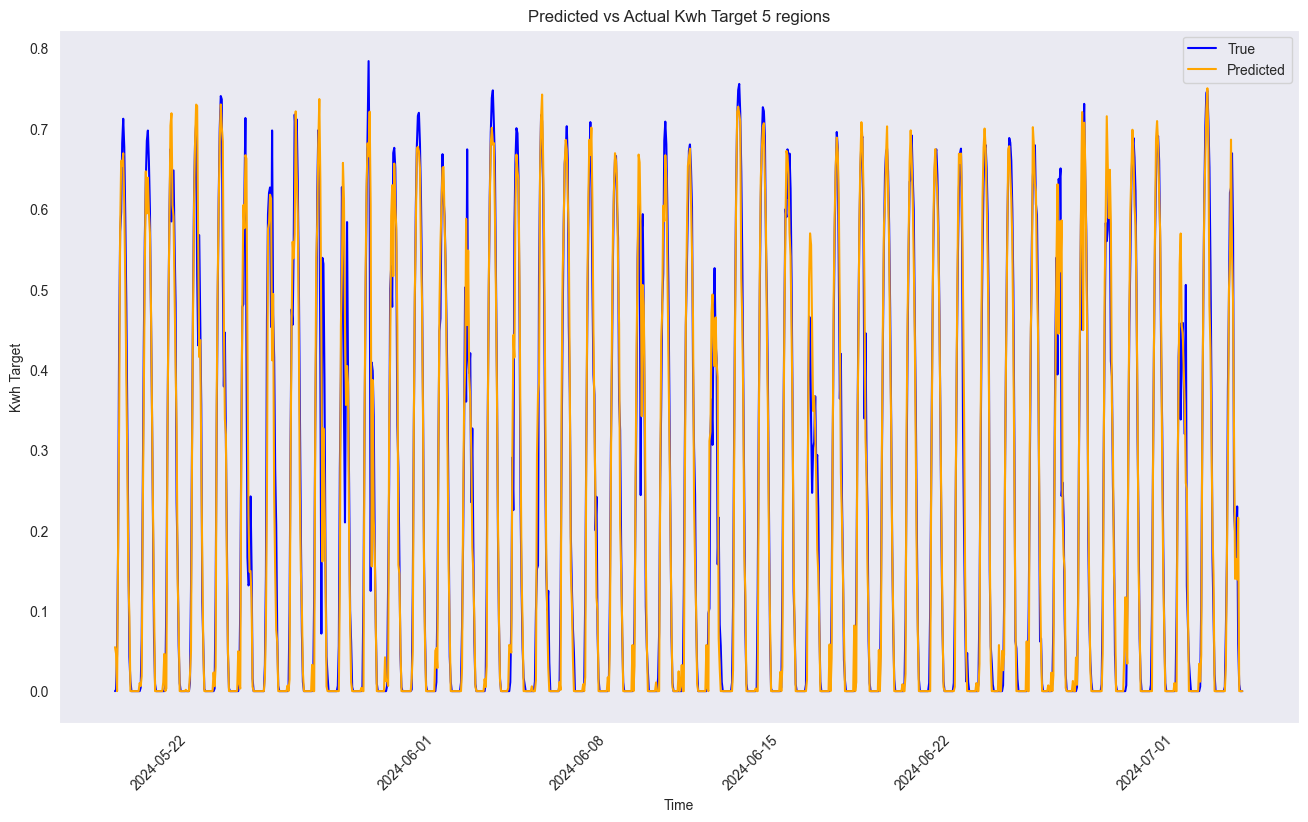

In [29]:
last_312_df = results_df.tail(1099)


plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target 5 regions')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [32]:
r2_score(y_pred_flat, y_test_flat)

0.9405296213098766

In [ ]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

In [ ]:
results_df[-168: - 144]

In [ ]:
results_df[-168: - 144].plot(figsize=(16, 9), marker = 'o')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target 5 Regions')

In [ ]:
mean_squared_error(results_df[-168: - 144]['Predicted'], 
                   results_df[-168: - 144]['True'])

In [ ]:
r2_score(results_df[-168: - 144]['Predicted'], 
         results_df[-168: - 144]['True'])

In [ ]:
results_df[-72: -48].plot(figsize= (16, 9), marker = "o")

In [ ]:
mean_squared_error(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

In [ ]:
r2_score(results_df[-72: -48]['Predicted'], results_df[-72: -48]['True'])

# Weather Analysis of the predictions

In [33]:
results_df = results_df.tail(-19)
results_df

,Predicted,True
2024-05-21 00:00:00,0.0000,0.0000
2024-05-21 01:00:00,0.0000,0.0000
2024-05-21 02:00:00,0.0000,0.0000
2024-05-21 03:00:00,0.0000,0.0000
2024-05-21 04:00:00,0.0000,0.0000
...,...,...
2024-07-04 19:00:00,0.2158,0.0592
2024-07-04 20:00:00,0.0000,0.0085
2024-07-04 21:00:00,0.0000,0.0000
2024-07-04 22:00:00,0.0000,0.0000


In [34]:
common_index = kwh_data.index.intersection(results_df.index)
common_index

DatetimeIndex(['2024-05-21 00:00:00', '2024-05-21 01:00:00',
               '2024-05-21 02:00:00', '2024-05-21 03:00:00',
               '2024-05-21 04:00:00', '2024-05-21 05:00:00',
               '2024-05-21 06:00:00', '2024-05-21 07:00:00',
               '2024-05-21 08:00:00', '2024-05-21 09:00:00',
               ...
               '2024-07-04 14:00:00', '2024-07-04 15:00:00',
               '2024-07-04 16:00:00', '2024-07-04 17:00:00',
               '2024-07-04 18:00:00', '2024-07-04 19:00:00',
               '2024-07-04 20:00:00', '2024-07-04 21:00:00',
               '2024-07-04 22:00:00', '2024-07-04 23:00:00'],
              dtype='datetime64[ns]', length=1080, freq='h')

In [35]:
data_cleaned = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data_cleaned.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_16972\2540193616.py:1: SyntaxWarning: invalid escape sequence '\D'
  data_cleaned = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [36]:
data_cleaned_same_index = data_cleaned.loc[common_index]
data_cleaned_same_index

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
2024-05-21 00:00:00,0.0000,"Kozani, Greece",17.0,17.0,15.0,88.00,0.0,0.0,0.0,13.5,5.4,160.0,1016.0,65.4,5.7,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 01:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,5.0,3.6,342.4,1016.0,94.1,1.9,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 02:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,4.7,3.6,350.2,1016.0,100.0,15.4,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 03:00:00,0.0000,"Kozani, Greece",15.0,15.0,14.0,93.72,0.0,0.0,0.0,15.3,5.4,237.0,1016.0,84.3,15.3,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 04:00:00,0.0000,"Kozani, Greece",14.0,14.0,14.0,100.00,0.0,0.0,0.0,6.8,5.4,350.2,1016.0,38.7,16.8,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain
2024-07-04 22:00:00,0.0000,"Kozani, Greece",20.0,20.0,11.0,56.15,0.0,0.0,0.0,14.0,0.0,0.0,1012.0,65.5,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [62]:
eval_df = pd.concat([data_cleaned_same_index["conditions"], results_df], axis= 1)
eval_df

,conditions,Predicted,True
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 01:00:00,Overcast,0.0000,0.0000
2024-05-21 02:00:00,Overcast,0.0000,0.0000
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000
...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.2158,0.0592
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0000,0.0085
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0000,0.0000
2024-07-04 22:00:00,Partially cloudy,0.0000,0.0000


In [63]:
eval_df['conditions'].value_counts()

conditions
Partially cloudy          556
Clear                     334
Overcast                  155
Rain, Overcast             16
Rain, Partially cloudy     16
Rain                        3
Name: count, dtype: int64

In [64]:
def categorize_condition(condition):
    if "Rain" in condition:
        return "Rain"
    elif "Clear" in condition:
        return "Clear"
    else:
        return "Cloudy"
    
    

eval_df["conditions_class"] = eval_df["conditions"].apply(categorize_condition)
eval_df

,conditions,Predicted,True,conditions_class
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000,Cloudy
...,...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.2158,0.0592,Cloudy
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0000,0.0085,Rain
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0000,0.0000,Rain
2024-07-04 22:00:00,Partially cloudy,0.0000,0.0000,Cloudy


In [65]:
eval_df = eval_df.drop('conditions', axis=1)
eval_df

,Predicted,True,conditions_class
2024-05-21 00:00:00,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,0.0000,0.0000,Cloudy
...,...,...,...
2024-07-04 19:00:00,0.2158,0.0592,Cloudy
2024-07-04 20:00:00,0.0000,0.0085,Rain
2024-07-04 21:00:00,0.0000,0.0000,Rain
2024-07-04 22:00:00,0.0000,0.0000,Cloudy


In [66]:
eval_df['team'] = (eval_df.reset_index().index // 24) + 1  
eval_df

,Predicted,True,conditions_class,team
2024-05-21 00:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 01:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 02:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 03:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 04:00:00,0.0000,0.0000,Cloudy,1
...,...,...,...,...
2024-07-04 19:00:00,0.2158,0.0592,Cloudy,45
2024-07-04 20:00:00,0.0000,0.0085,Rain,45
2024-07-04 21:00:00,0.0000,0.0000,Rain,45
2024-07-04 22:00:00,0.0000,0.0000,Cloudy,45


In [96]:
eval_df_non_zero = eval_df[eval_df['True'] != 0]
eval_df_non_zero

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0063,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0187,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2164,0.2481,Cloudy,1
2024-05-21 09:00:00,0.3608,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5233,0.5608,Cloudy,1
...,...,...,...,...
2024-07-04 16:00:00,0.1397,0.1976,Cloudy,45
2024-07-04 17:00:00,0.1644,0.1672,Cloudy,45
2024-07-04 18:00:00,0.1390,0.2298,Rain,45
2024-07-04 19:00:00,0.2158,0.0592,Cloudy,45


In [117]:
cloudy_eval_df_non_zero = eval_df_non_zero[eval_df_non_zero['conditions_class'] == "Cloudy"]
cloudy_eval_df_non_zero.head(50)

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0063,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0187,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2164,0.2481,Cloudy,1
2024-05-21 09:00:00,0.3608,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5233,0.5608,Cloudy,1
2024-05-21 11:00:00,0.6468,0.6357,Cloudy,1
2024-05-21 12:00:00,0.5944,0.6848,Cloudy,1
2024-05-21 13:00:00,0.6388,0.6975,Cloudy,1
2024-05-21 14:00:00,0.5958,0.6589,Cloudy,1
2024-05-21 15:00:00,0.5700,0.5991,Cloudy,1


In [121]:
cloudy_data_frame_grouped = cloudy_eval_df_non_zero['conditions_class'].groupby(cloudy_eval_df_non_zero.index.date).value_counts() > 10
cloudy_data_frame_grouped

            conditions_class
2024-05-21  Cloudy               True
2024-05-22  Cloudy              False
2024-05-23  Cloudy               True
2024-05-24  Cloudy              False
2024-05-25  Cloudy               True
2024-05-26  Cloudy              False
2024-05-27  Cloudy               True
2024-05-28  Cloudy               True
2024-05-29  Cloudy               True
2024-05-30  Cloudy               True
2024-05-31  Cloudy               True
2024-06-01  Cloudy              False
2024-06-02  Cloudy               True
2024-06-03  Cloudy               True
2024-06-04  Cloudy               True
2024-06-05  Cloudy               True
2024-06-06  Cloudy               True
2024-06-07  Cloudy              False
2024-06-08  Cloudy              False
2024-06-09  Cloudy              False
2024-06-10  Cloudy               True
2024-06-11  Cloudy               True
2024-06-12  Cloudy               True
2024-06-13  Cloudy               True
2024-06-14  Cloudy              False
2024-06-15  Cloudy   

In [122]:
cloudy_data_frame_grouped.value_counts()

count
True     25
False    20
Name: count, dtype: int64

In [123]:
daily_r2_scores = {}
grouped = eval_df.groupby(eval_df.index.date)  

for date, group in grouped:
    r2 = r2_score(group["True"], group["Predicted"])
    daily_r2_scores[date] = r2
    
r2_df = pd.DataFrame(list(daily_r2_scores.items()), columns=["Date", "R2_Score"])
print(r2_df)


          Date  R2_Score
0   2024-05-21  0.983817
1   2024-05-22  0.965520
2   2024-05-23  0.938370
3   2024-05-24  0.965915
4   2024-05-25  0.849769
5   2024-05-26  0.853727
6   2024-05-27  0.962763
7   2024-05-28  0.720450
8   2024-05-29  0.785090
9   2024-05-30  0.778613
10  2024-05-31  0.927610
11  2024-06-01  0.991896
12  2024-06-02  0.978545
13  2024-06-03  0.829564
14  2024-06-04  0.989257
15  2024-06-05  0.941984
16  2024-06-06  0.923869
17  2024-06-07  0.973899
18  2024-06-08  0.966286
19  2024-06-09  0.978636
20  2024-06-10  0.853610
21  2024-06-11  0.970681
22  2024-06-12  0.973398
23  2024-06-13  0.731575
24  2024-06-14  0.981589
25  2024-06-15  0.985243
26  2024-06-16  0.976507
27  2024-06-17  0.784113
28  2024-06-18  0.965821
29  2024-06-19  0.955486
30  2024-06-20  0.991488
31  2024-06-21  0.985292
32  2024-06-22  0.990920
33  2024-06-23  0.948335
34  2024-06-24  0.985969
35  2024-06-25  0.985398
36  2024-06-26  0.976380
37  2024-06-27  0.809451
38  2024-06-28  0.920994


In [60]:
grouped["True"]

In [ ]:
r2_df = pd.concat([r2_df, ])